### 1. Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, pointbiserialr, mannwhitneyu
import warnings
warnings.filterwarnings('ignore')
 
sns.set_theme(style="whitegrid")
ACCENT = '#5C4EDB'
 
df = pd.read_csv('../data/processed/hr_cleaned.csv')
print(f"Dataset loaded: {df.shape}")

Dataset loaded: (1470, 39)


### 2. Chi-Square Tests - Categorical Variables vs Attrition

In [3]:

def chi_square_test(df, col, target='Attrition'):
    """Run chi-square test for independence between col and attrition."""
    contingency = pd.crosstab(df[col], df[target])
    chi2, p, dof, expected = chi2_contingency(contingency)
    return {
        'Feature': col,
        'Chi2': round(chi2, 3),
        'p-value': round(p, 4),
        'DOF': dof,
        'Significant (p<0.05)': 'YES ✓' if p < 0.05 else 'No'
    }
 
categorical_cols = [
    'Department', 'JobRole', 'OverTime', 'BusinessTravel',
    'MaritalStatus', 'Gender', 'EducationField',
    'SalaryBand', 'TenureGroup', 'AgeGroup', 'JobSatisfactionLabel'
]
 
chi2_results = pd.DataFrame([chi_square_test(df, c) for c in categorical_cols])
chi2_results = chi2_results.sort_values('Chi2', ascending=False)
 
print("\n=== Chi-Square Test Results ===")
print(chi2_results.to_string(index=False))
 


=== Chi-Square Test Results ===
             Feature   Chi2  p-value  DOF Significant (p<0.05)
            OverTime 87.564   0.0000    1                YES ✓
             JobRole 86.190   0.0000    8                YES ✓
         TenureGroup 75.811   0.0000    3                YES ✓
            AgeGroup 64.882   0.0000    4                YES ✓
          SalaryBand 64.287   0.0000    3                YES ✓
       MaritalStatus 46.164   0.0000    2                YES ✓
      BusinessTravel 24.182   0.0000    2                YES ✓
JobSatisfactionLabel 17.505   0.0006    3                YES ✓
      EducationField 16.025   0.0068    5                YES ✓
          Department 10.796   0.0045    2                YES ✓
              Gender  1.117   0.2906    1                   No


### 3. Point-Biserial Correlation — Continuous Variables vs Attrition

In [5]:
def pbr_test(df, col, target='AttritionFlag'):
    """Point-biserial correlation: continuous feature vs binary attrition."""
    clean = df[[col, target]].dropna()
    corr, p = pointbiserialr(clean[target], clean[col])
    return {
        'Feature': col,
        'Correlation': round(corr, 4),
        'p-value': round(p, 4),
        'Direction': 'Higher → More attrition ↑' if corr > 0 else 'Higher → Less attrition ↓',
        'Significant': 'YES ✓' if p < 0.05 else 'No'
    }
 
numeric_cols = [
    'Age', 'MonthlyIncome', 'DailyRate', 'HourlyRate', 'MonthlyRate',
    'YearsAtCompany', 'TotalWorkingYears', 'YearsInCurrentRole',
    'YearsSinceLastPromotion', 'YearsWithCurrManager',
    'JobSatisfaction', 'EnvironmentSatisfaction',
    'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating',
    'DistanceFromHome', 'NumCompaniesWorked', 'PercentSalaryHike',
    'TrainingTimesLastYear', 'StockOptionLevel', 'RiskScore'
]
 
pbr_results = pd.DataFrame([pbr_test(df, c) for c in numeric_cols])
pbr_results = pbr_results.sort_values('Correlation', key=abs, ascending=False)
 
print("\n=== Point-Biserial Correlation Results ===")
print(pbr_results.to_string(index=False))


=== Point-Biserial Correlation Results ===
                Feature  Correlation  p-value                 Direction Significant
              RiskScore       0.3459   0.0000 Higher → More attrition ↑       YES ✓
      TotalWorkingYears      -0.1711   0.0000 Higher → Less attrition ↓       YES ✓
     YearsInCurrentRole      -0.1605   0.0000 Higher → Less attrition ↓       YES ✓
          MonthlyIncome      -0.1598   0.0000 Higher → Less attrition ↓       YES ✓
                    Age      -0.1592   0.0000 Higher → Less attrition ↓       YES ✓
   YearsWithCurrManager      -0.1562   0.0000 Higher → Less attrition ↓       YES ✓
       StockOptionLevel      -0.1371   0.0000 Higher → Less attrition ↓       YES ✓
         YearsAtCompany      -0.1344   0.0000 Higher → Less attrition ↓       YES ✓
         JobInvolvement      -0.1300   0.0000 Higher → Less attrition ↓       YES ✓
        JobSatisfaction      -0.1035   0.0001 Higher → Less attrition ↓       YES ✓
EnvironmentSatisfaction      -0.

### 4. Correaltion Heatmap - Top Features

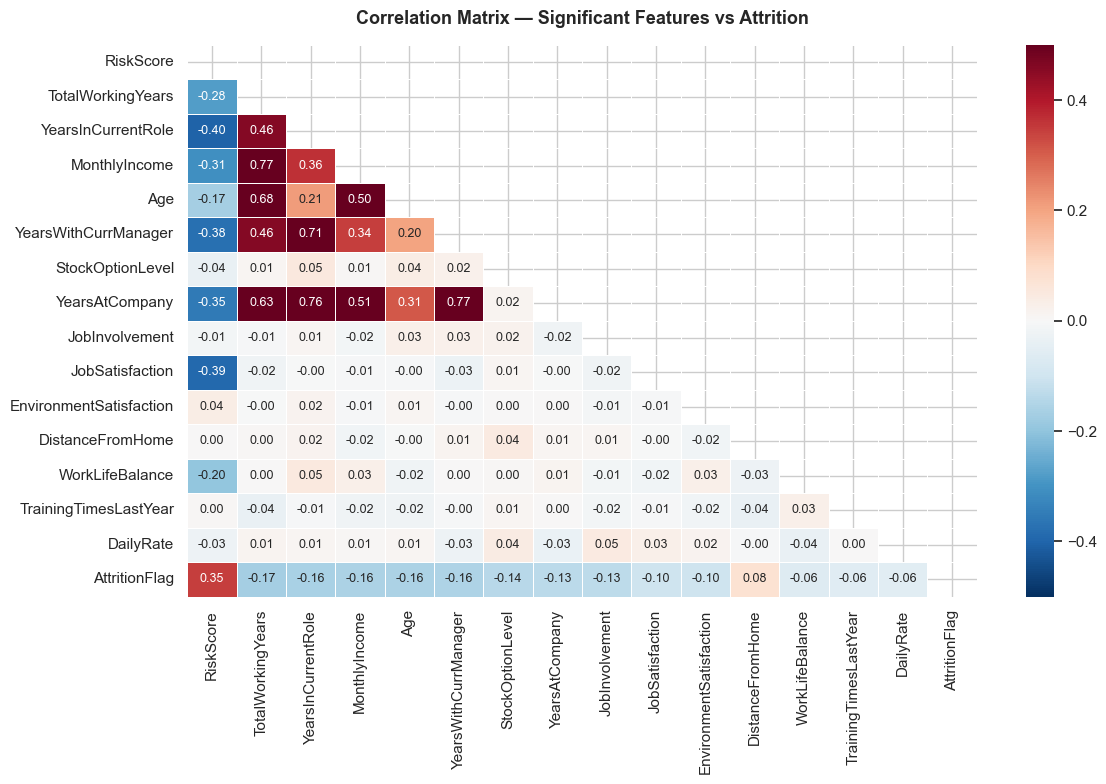

In [6]:
top_features = pbr_results[pbr_results['Significant'] == 'YES ✓']['Feature'].tolist()
top_features.append('AttritionFlag')
 
corr_matrix = df[top_features].corr()
 
fig, ax = plt.subplots(figsize=(12, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, ax=ax, vmin=-0.5, vmax=0.5,
            annot_kws={'size': 9})
ax.set_title('Correlation Matrix — Significant Features vs Attrition',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('../reports/fig_09_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 5. Mann-Whitney U Test — Income difference between Stayed vs Left

In [7]:
stayed = df[df['Attrition'] == 'No']['MonthlyIncome']
left   = df[df['Attrition'] == 'Yes']['MonthlyIncome']
 
u_stat, p_value = mannwhitneyu(stayed, left, alternative='greater')
 
print("=== Mann-Whitney U Test: Monthly Income ===")
print(f"H0: Income distribution is the same for employees who stayed vs left")
print(f"H1: Employees who stayed have significantly higher income\n")
print(f"U-statistic : {u_stat:.0f}")
print(f"p-value     : {p_value:.6f}")
print(f"Result      : {'REJECT H0 — significant income difference ✓' if p_value < 0.05 else 'Fail to reject H0'}")
print(f"\nMedian income — Stayed: ${stayed.median():,.0f} | Left: ${left.median():,.0f}")
print(f"Mean income  — Stayed: ${stayed.mean():,.0f}   | Left: ${left.mean():,.0f}")
 

=== Mann-Whitney U Test: Monthly Income ===
H0: Income distribution is the same for employees who stayed vs left
H1: Employees who stayed have significantly higher income

U-statistic : 191600
p-value     : 0.000000
Result      : REJECT H0 — significant income difference ✓

Median income — Stayed: $5,204 | Left: $3,202
Mean income  — Stayed: $6,833   | Left: $4,787


### 6. Tenure Attrition Rate — 3× Finding Validation

In [8]:
tenure_order = ['< 2 years', '2-5 years', '5-10 years', '10+ years']
tenure_rates = (df.groupby('TenureGroup')['AttritionFlag']
                  .mean()
                  .reindex(tenure_order) * 100)
 
print("\n=== Tenure Group Attrition Rates ===")
for group, rate in tenure_rates.items():
    print(f"  {group:<15} → {rate:.1f}%")
 
base_rate = tenure_rates['10+ years']
early_rate = tenure_rates['< 2 years']
multiplier = early_rate / base_rate
print(f"\nKey Finding: Early-career employees ({early_rate:.1f}%) attrite "
      f"{multiplier:.1f}× more than tenured staff ({base_rate:.1f}%)")


=== Tenure Group Attrition Rates ===
  < 2 years       → 34.9%
  2-5 years       → 18.1%
  5-10 years      → 11.1%
  10+ years       → 10.4%

Key Finding: Early-career employees (34.9%) attrite 3.4× more than tenured staff (10.4%)


### 7. Risk Score Analysis

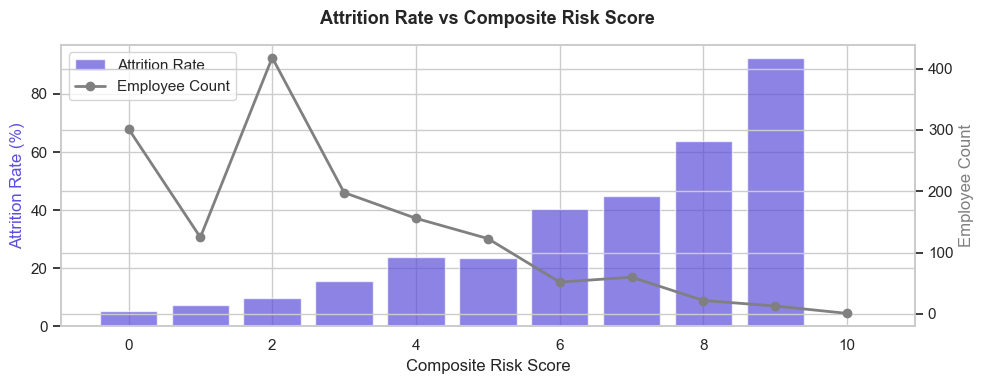

In [9]:
risk_agg = (df.groupby('RiskScore')['AttritionFlag']
              .agg(['mean', 'count'])
              .rename(columns={'mean': 'AttritionRate', 'count': 'Count'})
              .reset_index())
risk_agg['AttritionPct'] = risk_agg['AttritionRate'] * 100
 
fig, ax1 = plt.subplots(figsize=(10, 4))
ax2 = ax1.twinx()
 
ax1.bar(risk_agg['RiskScore'], risk_agg['AttritionPct'],
        color=ACCENT, alpha=0.7, label='Attrition Rate')
ax2.plot(risk_agg['RiskScore'], risk_agg['Count'],
         color='gray', marker='o', linewidth=2, label='Employee Count')
 
ax1.set_xlabel('Composite Risk Score')
ax1.set_ylabel('Attrition Rate (%)', color=ACCENT)
ax2.set_ylabel('Employee Count', color='gray')
ax1.set_title('Attrition Rate vs Composite Risk Score',
              fontsize=13, fontweight='bold', pad=15)
 
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('../reports/fig_10_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()

### 8. Summary of Statistical Findings

In [10]:
print("=" * 60)
print("STATISTICAL ANALYSIS SUMMARY")
print("=" * 60)
 
sig_chi2 = chi2_results[chi2_results['Significant (p<0.05)'] == 'YES ✓']
sig_pbr  = pbr_results[pbr_results['Significant'] == 'YES ✓']
 
print(f"\n✅ Significant categorical predictors ({len(sig_chi2)}):")
for _, row in sig_chi2.iterrows():
    print(f"   {row['Feature']:<30} χ²={row['Chi2']:.1f}, p={row['p-value']}")
 
print(f"\n✅ Significant continuous predictors ({len(sig_pbr)}):")
for _, row in sig_pbr.head(10).iterrows():
    print(f"   {row['Feature']:<30} r={row['Correlation']:.3f}  {row['Direction']}")
 
print("\n✅ Mann-Whitney: Income significantly differs between attrition groups")
print(f"✅ Tenure finding: Early-career employees attrite {multiplier:.1f}× more")
print("\n🎯 Top 3 actionable insights:")
print("   1. Target retention programs at employees in first 2 years")
print("   2. Review compensation for Low salary band employees")
print("   3. Address overtime policies — 3× attrition risk for OT workers")

STATISTICAL ANALYSIS SUMMARY

✅ Significant categorical predictors (10):
   OverTime                       χ²=87.6, p=0.0
   JobRole                        χ²=86.2, p=0.0
   TenureGroup                    χ²=75.8, p=0.0
   AgeGroup                       χ²=64.9, p=0.0
   SalaryBand                     χ²=64.3, p=0.0
   MaritalStatus                  χ²=46.2, p=0.0
   BusinessTravel                 χ²=24.2, p=0.0
   JobSatisfactionLabel           χ²=17.5, p=0.0006
   EducationField                 χ²=16.0, p=0.0068
   Department                     χ²=10.8, p=0.0045

✅ Significant continuous predictors (15):
   RiskScore                      r=0.346  Higher → More attrition ↑
   TotalWorkingYears              r=-0.171  Higher → Less attrition ↓
   YearsInCurrentRole             r=-0.161  Higher → Less attrition ↓
   MonthlyIncome                  r=-0.160  Higher → Less attrition ↓
   Age                            r=-0.159  Higher → Less attrition ↓
   YearsWithCurrManager           r=